Shape: (17510, 22)

Columns:
['event_id', 'storm', 'geoid', 'county', 'datetime', 'event_start', 'duration_hours', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c', 'CountyFIPS', 'outageFraction', 'customersTracked', 'persistence_1h', 'error', 'abs_error', 'sq_error', 'persistence_24h', 'persistence_48h', 'persistence_72h']

OutageFraction summary:
count    17510.000000
mean         0.332610
std          0.300939
min          0.000000
25%          0.067767
50%          0.248203
75%          0.549328
max          1.000000
Name: outageFraction, dtype: float64

Plotting groups 0 to 20


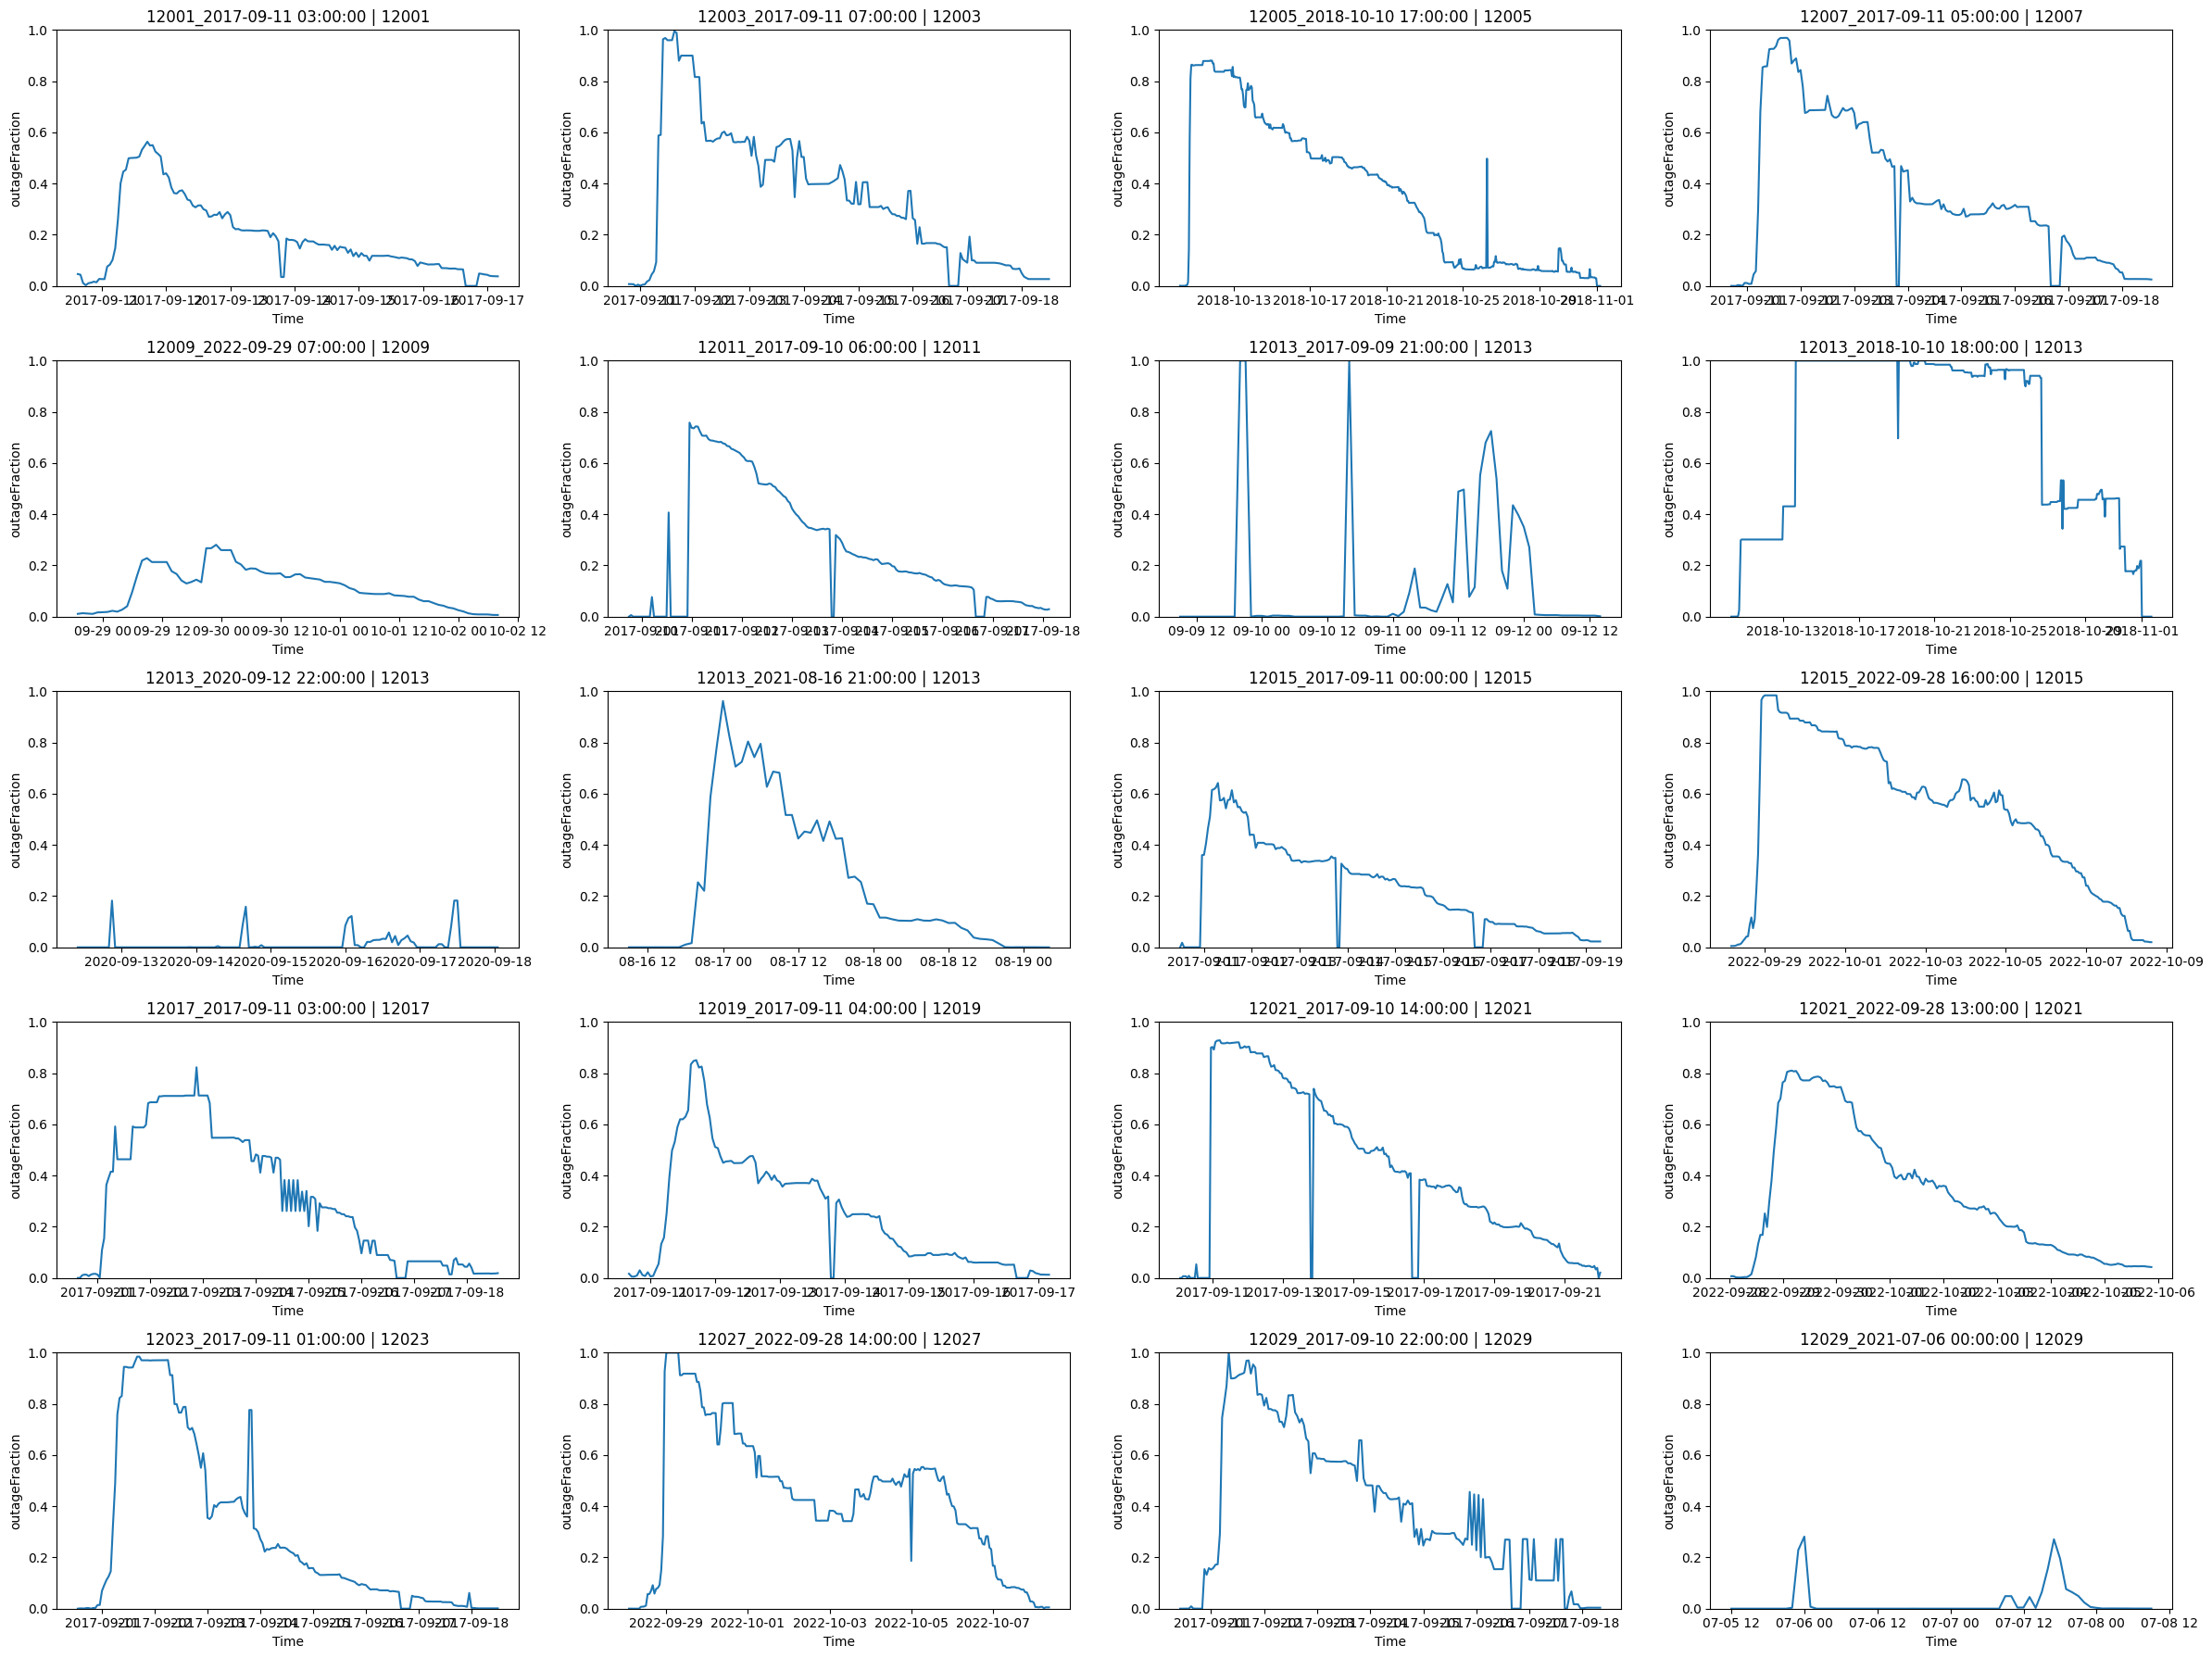

In [1]:
# CELL 1 — Load + basic inspection + multi-plot of outageFraction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_model_df.parquet"
)

# Basic formatting
df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df = df.sort_values(["event_id", "CountyFIPS", "datetime"])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nOutageFraction summary:")
print(df["outageFraction"].describe())

# ---- MULTI-PLOT ----

# Parameters you can tweak
chunk = 1
plots_per_chunk = 20

groups = (
    df[["event_id", "CountyFIPS"]]
    .drop_duplicates()
    .sort_values(["event_id", "CountyFIPS"])
    .reset_index(drop=True)
)

start = (chunk - 1) * plots_per_chunk
end = start + plots_per_chunk

print(f"\nPlotting groups {start} to {end}")

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start:end].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]

    g = df[
        (df["event_id"] == event_id) &
        (df["CountyFIPS"] == county_fips)
    ].sort_values("datetime")

    s = g["outageFraction"].astype(float)

    ax.set_visible(True)
    ax.plot(g["datetime"], s, linewidth=1.5)

    ax.set_title(f"{event_id} | {county_fips}")
    ax.set_xlabel("Time")
    ax.set_ylabel("outageFraction")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

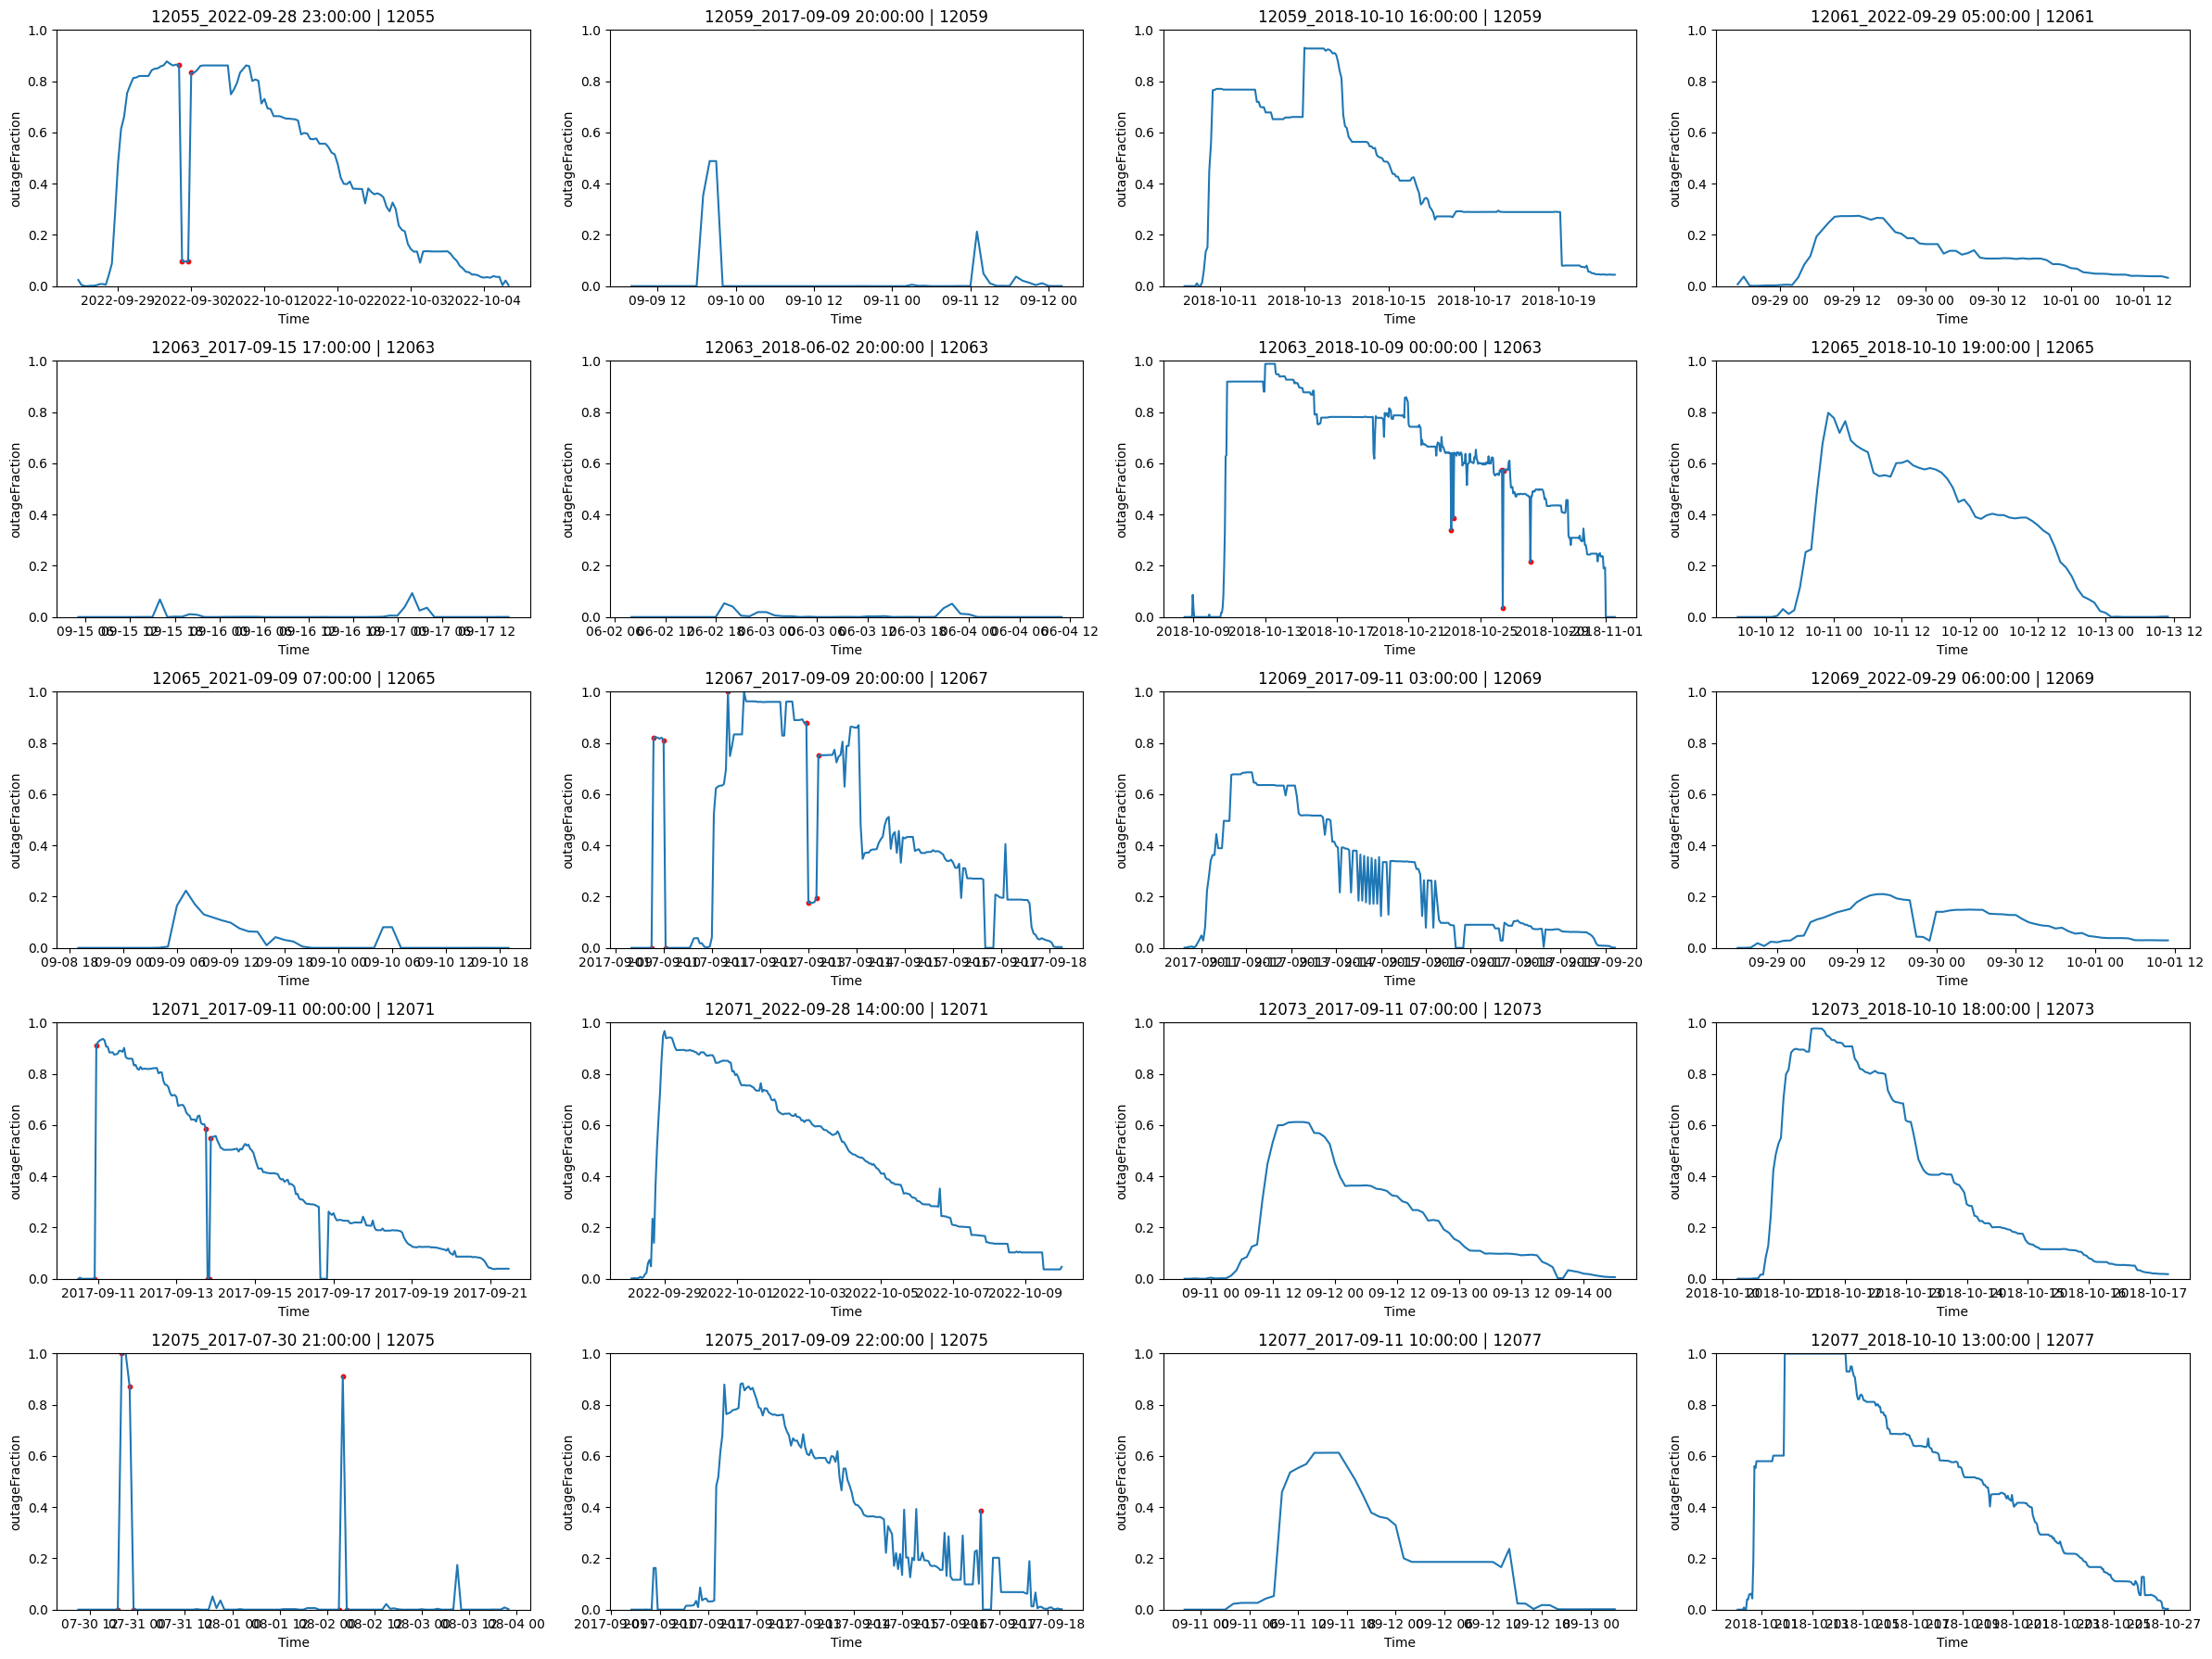

In [6]:
# CELL — Simple local anomaly detection + visual validation (20 plots)

chunk = 3
plots_per_chunk = 20

# thresholds (start conservative)
spike_up_thresh = 0.25
spike_down_thresh = 0.25

groups = (
    df[["event_id", "CountyFIPS"]]
    .drop_duplicates()
    .sort_values(["event_id", "CountyFIPS"])
    .reset_index(drop=True)
)

start = (chunk - 1) * plots_per_chunk
end = start + plots_per_chunk

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start:end].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]

    g = df[
        (df["event_id"] == event_id) &
        (df["CountyFIPS"] == county_fips)
    ].sort_values("datetime").copy()

    s = g["outageFraction"].astype(float)

    prev = s.shift(1)
    next_ = s.shift(-1)

    local_mean = (prev + next_) / 2

    spike_up = (s - local_mean) > spike_up_thresh
    spike_down = (local_mean - s) > spike_down_thresh

    flag = spike_up | spike_down

    ax.set_visible(True)

    ax.plot(g["datetime"], s, linewidth=1.5)
    ax.scatter(g.loc[flag, "datetime"], s[flag], color="red", s=10)

    ax.set_title(f"{event_id} | {county_fips}")
    ax.set_xlabel("Time")
    ax.set_ylabel("outageFraction")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

let's look at this 12063 storm

Event: 12063_2018-06-02 20:00:00
Storm ID: 2018146N19273

Counties involved: 1
['12063']

Date range:
2018-06-02 08:00:00 → 2018-06-04 11:00:00

Top counties by max outage:
CountyFIPS  max_outage  duration               start
     12063     0.05356        28 2018-06-02 20:00:00


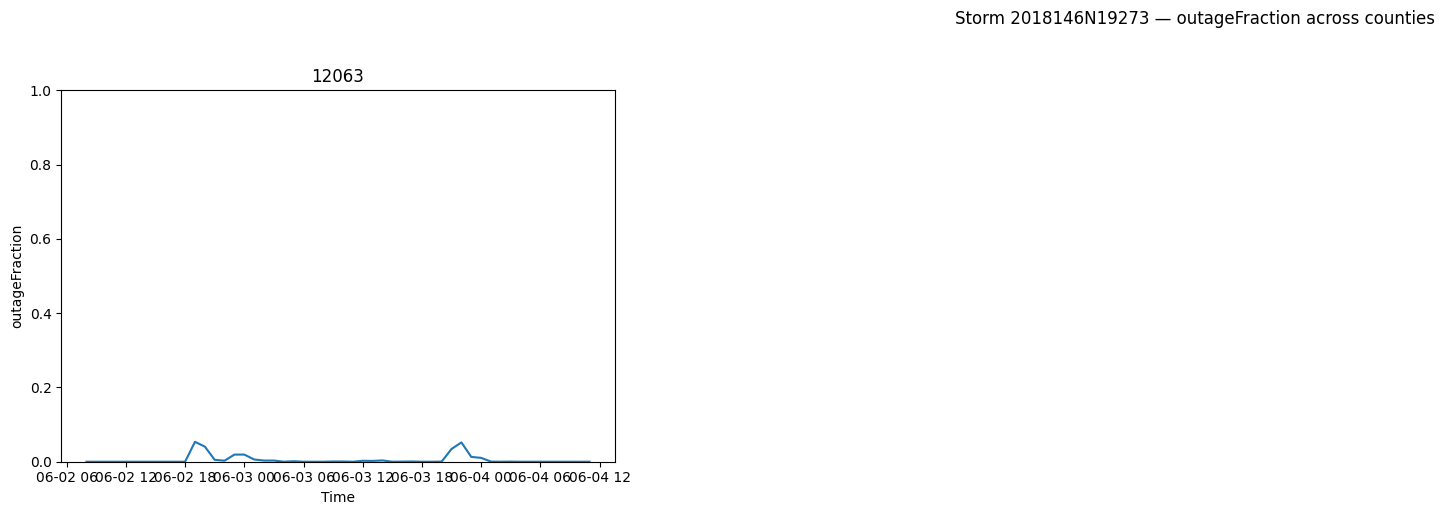


IBTrACS matches:
2018146N19273  bal012018 ALBERTO[hurdat_atl] = bal012018[atcf]


In [7]:
# CELL — inspect full storm across counties

import pandas as pd
import matplotlib.pyplot as plt

event_id = "12063_2018-06-02 20:00:00"

# --- 1. identify storm ---
row = df[df["event_id"] == event_id].iloc[0]
storm_id = row["storm"]

print("Event:", event_id)
print("Storm ID:", storm_id)

# --- 2. subset storm ---
storm_df = df[df["storm"] == storm_id].copy()

counties = storm_df["CountyFIPS"].unique()
print("\nCounties involved:", len(counties))
print(sorted(counties))

print("\nDate range:")
print(storm_df["datetime"].min(), "→", storm_df["datetime"].max())

# --- 3. event-level summary per county ---
summary = (
    storm_df.groupby("CountyFIPS")
    .agg(
        max_outage=("outageFraction", "max"),
        duration=("duration_hours", "max"),
        start=("event_start", "min"),
    )
    .reset_index()
    .sort_values("max_outage", ascending=False)
)

print("\nTop counties by max outage:")
print(summary.head(10).to_string(index=False))

# --- 4. plot all counties (outageFraction) ---
n = len(counties)
cols = 4
rows = (n // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(24, 5*rows))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, county in zip(axes, counties):
    g = storm_df[storm_df["CountyFIPS"] == county].sort_values("datetime")

    ax.set_visible(True)
    ax.plot(g["datetime"], g["outageFraction"])

    ax.set_title(f"{county}")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time")
    ax.set_ylabel("outageFraction")

plt.suptitle(f"Storm {storm_id} — outageFraction across counties", y=1.02)
plt.tight_layout()
plt.show()

# --- 5. optional: look up storm name in ibtracs ---
ib_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\ibtracs.txt"

try:
    with open(ib_path, "r") as f:
        lines = f.readlines()

    matches = [l for l in lines if storm_id in l]

    print("\nIBTrACS matches:")
    for m in matches[:5]:
        print(m.strip())

except Exception as e:
    print("\nCould not read ibtracs file:", e)

^only one 'event' during that hurricane apparently

In [8]:
# CELL — search for all outages in date window

start = pd.Timestamp("2018-05-25")
end = pd.Timestamp("2018-06-10")

window_df = df[
    (df["datetime"] >= start) &
    (df["datetime"] <= end)
].copy()

print("Total rows in window:", len(window_df))

# Event-level summary
summary = (
    window_df.groupby(["event_id", "CountyFIPS"])
    .agg(
        max_outage=("outageFraction", "max"),
        duration=("duration_hours", "max"),
        storm=("storm", "first"),
    )
    .reset_index()
    .sort_values("max_outage", ascending=False)
)

print("\nTop events in this window:")
print(summary.head(20).to_string(index=False))

print("\nNumber of unique events:", summary["event_id"].nunique())
print("Number of unique storms:", summary["storm"].nunique())

# Optional: filter to only meaningful outages
meaningful = summary[summary["max_outage"] > 0.1]

print("\nMeaningful events (max_outage > 0.1):")
print(meaningful.to_string(index=False))
print("\nCount:", len(meaningful))

Total rows in window: 52

Top events in this window:
                 event_id CountyFIPS  max_outage  duration         storm
12063_2018-06-02 20:00:00      12063     0.05356        28 2018146N19273

Number of unique events: 1
Number of unique storms: 1

Meaningful events (max_outage > 0.1):
Empty DataFrame
Columns: [event_id, CountyFIPS, max_outage, duration, storm]
Index: []

Count: 0


let's look at other states too (beyond FL)

Storm ID: 2018146N19273
Counties in POUS: 27
Date window: 2018-05-25 11:00:00 → 2018-06-04 12:00:00

POUS county summary:
CountyFIPS         event_start  duration_hours  county_pop
     21219 2018-05-25 23:00:00             191       12404
     26125 2018-05-28 21:00:00              69     1269431
     26161 2018-05-28 22:00:00              68      366376
     18061 2018-05-30 11:00:00              58       39851
     17151 2018-06-01 18:00:00              54        3770
     39037 2018-05-27 20:00:00              50       51529
     18079 2018-05-31 20:00:00              48       27536
     01077 2018-05-29 07:00:00              45       95878
     01059 2018-05-30 23:00:00              40       31932
     47117 2018-05-30 03:00:00              39       35878
     47023 2018-06-01 23:00:00              38       17609
     26035 2018-05-27 08:00:00              36       31352
     21039 2018-05-27 13:00:00              34        4720
     21091 2018-05-30 14:00:00              34      

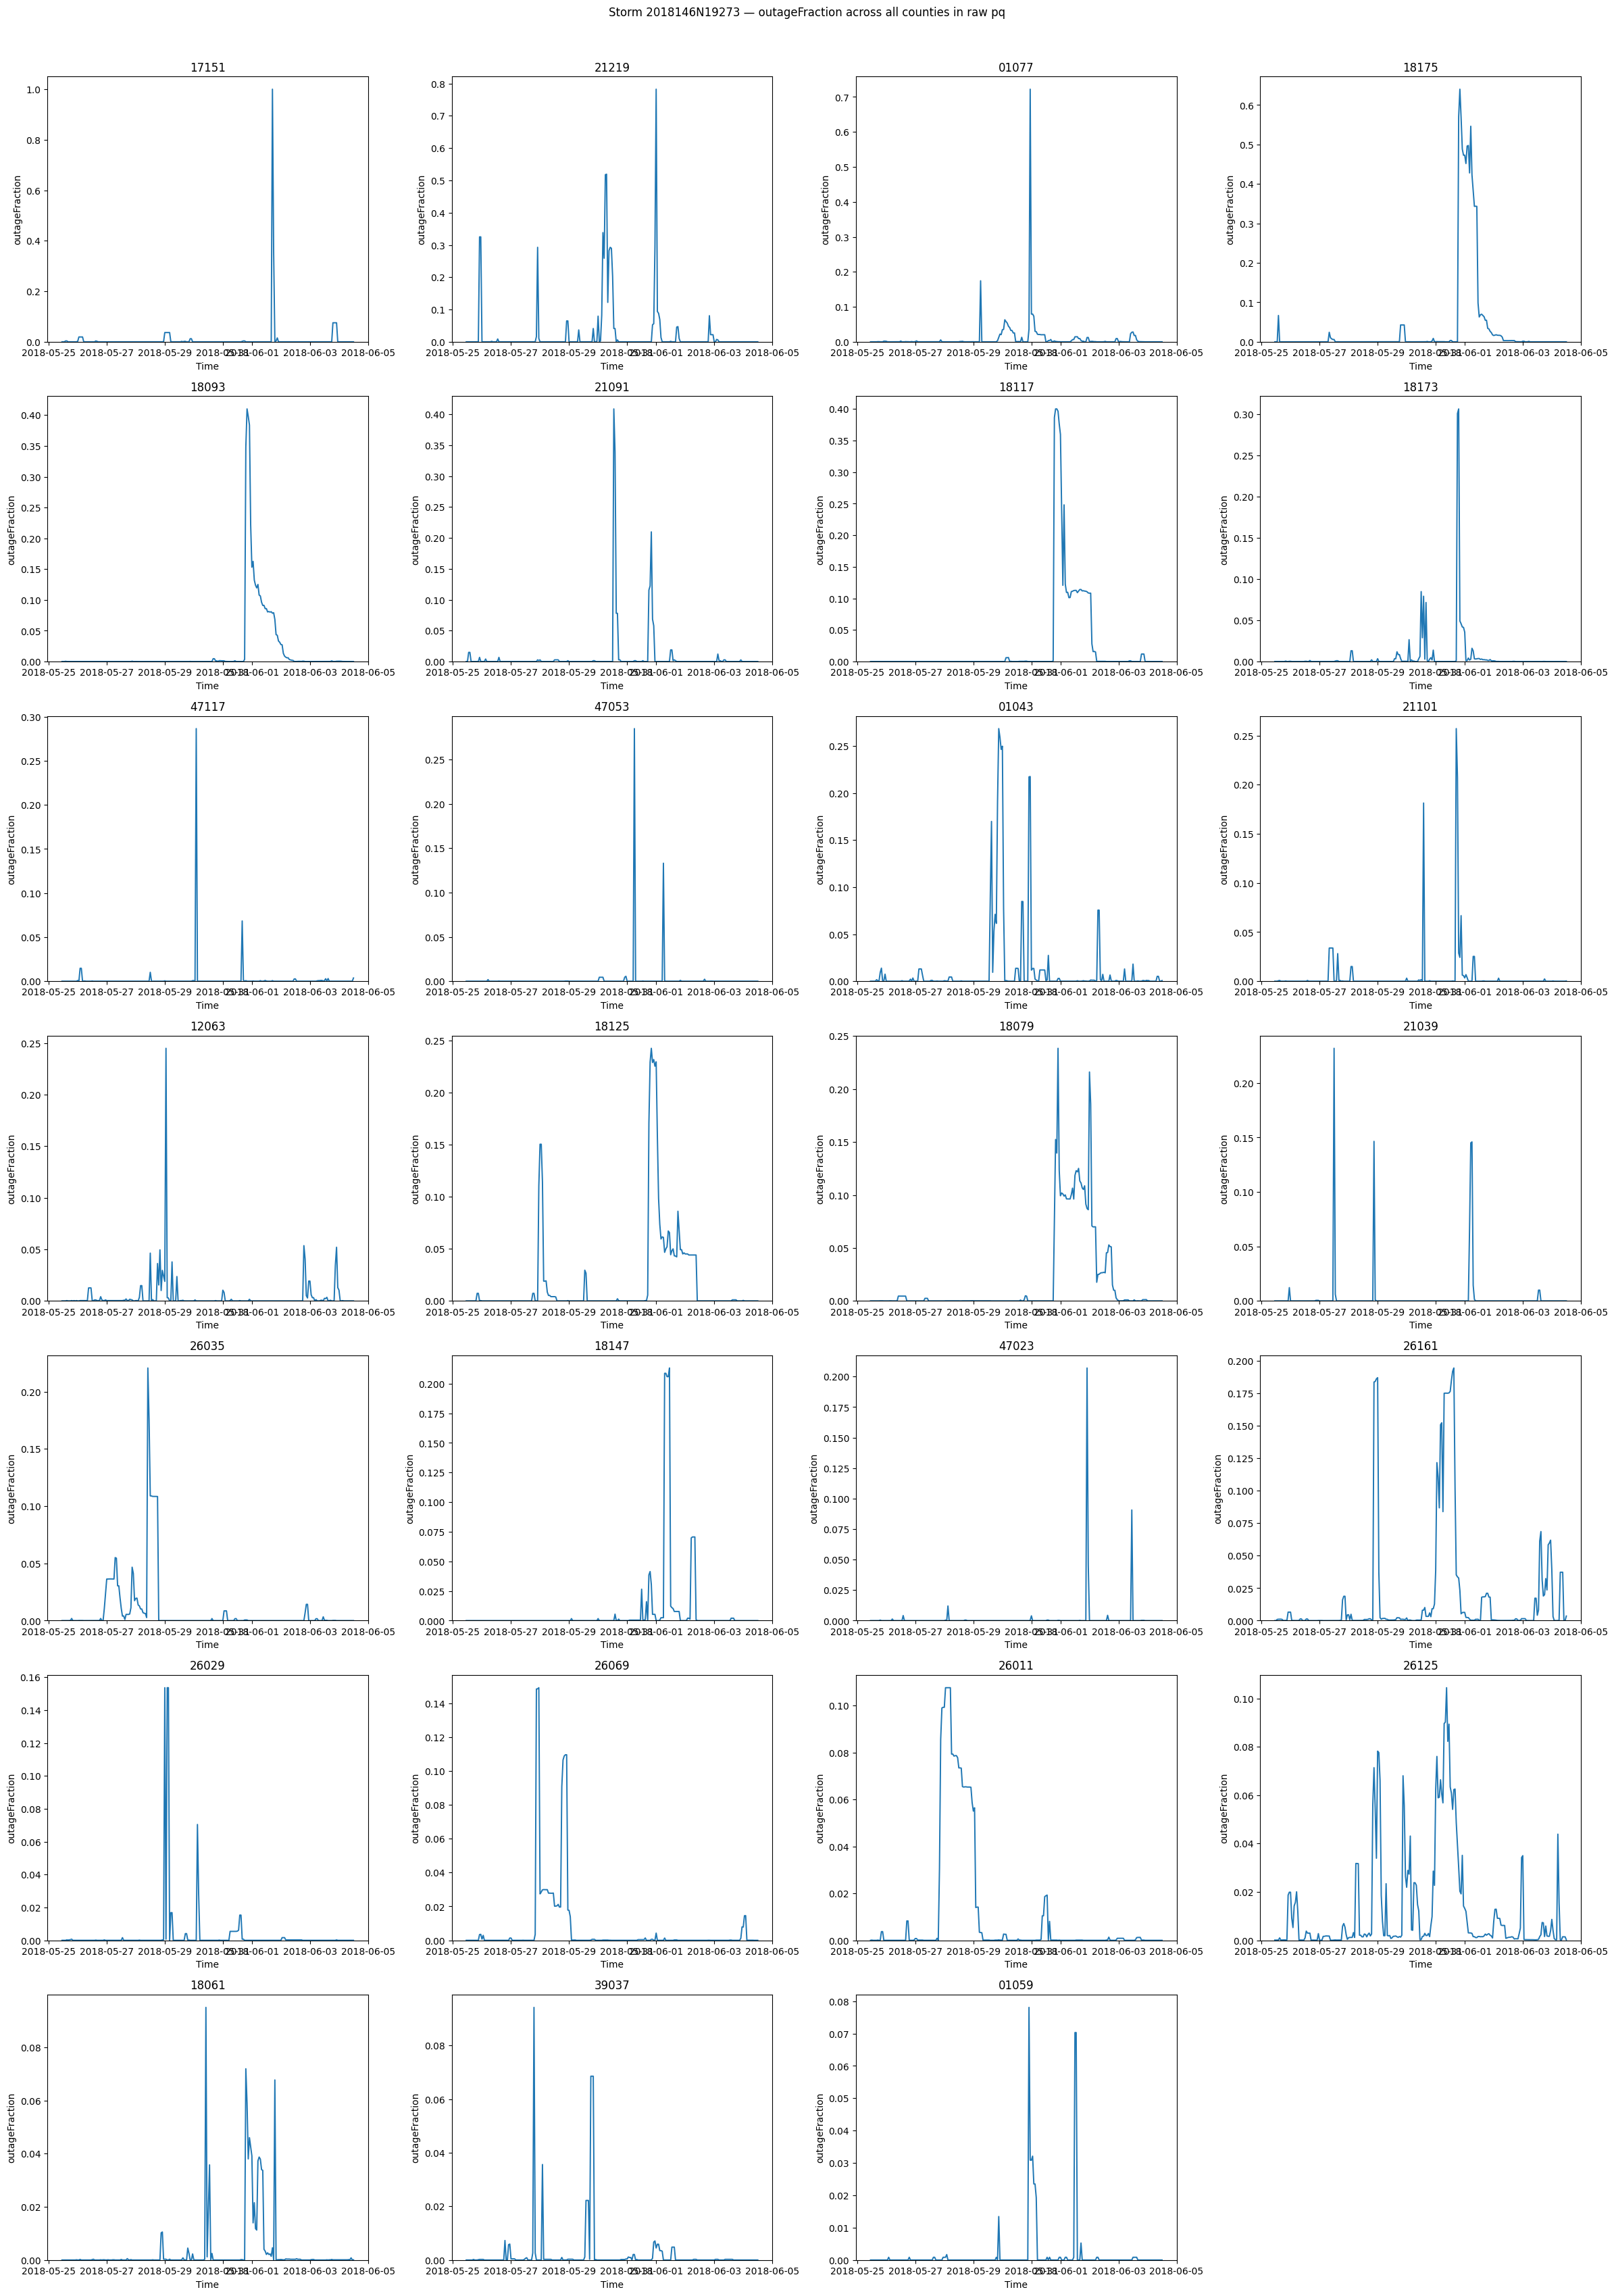

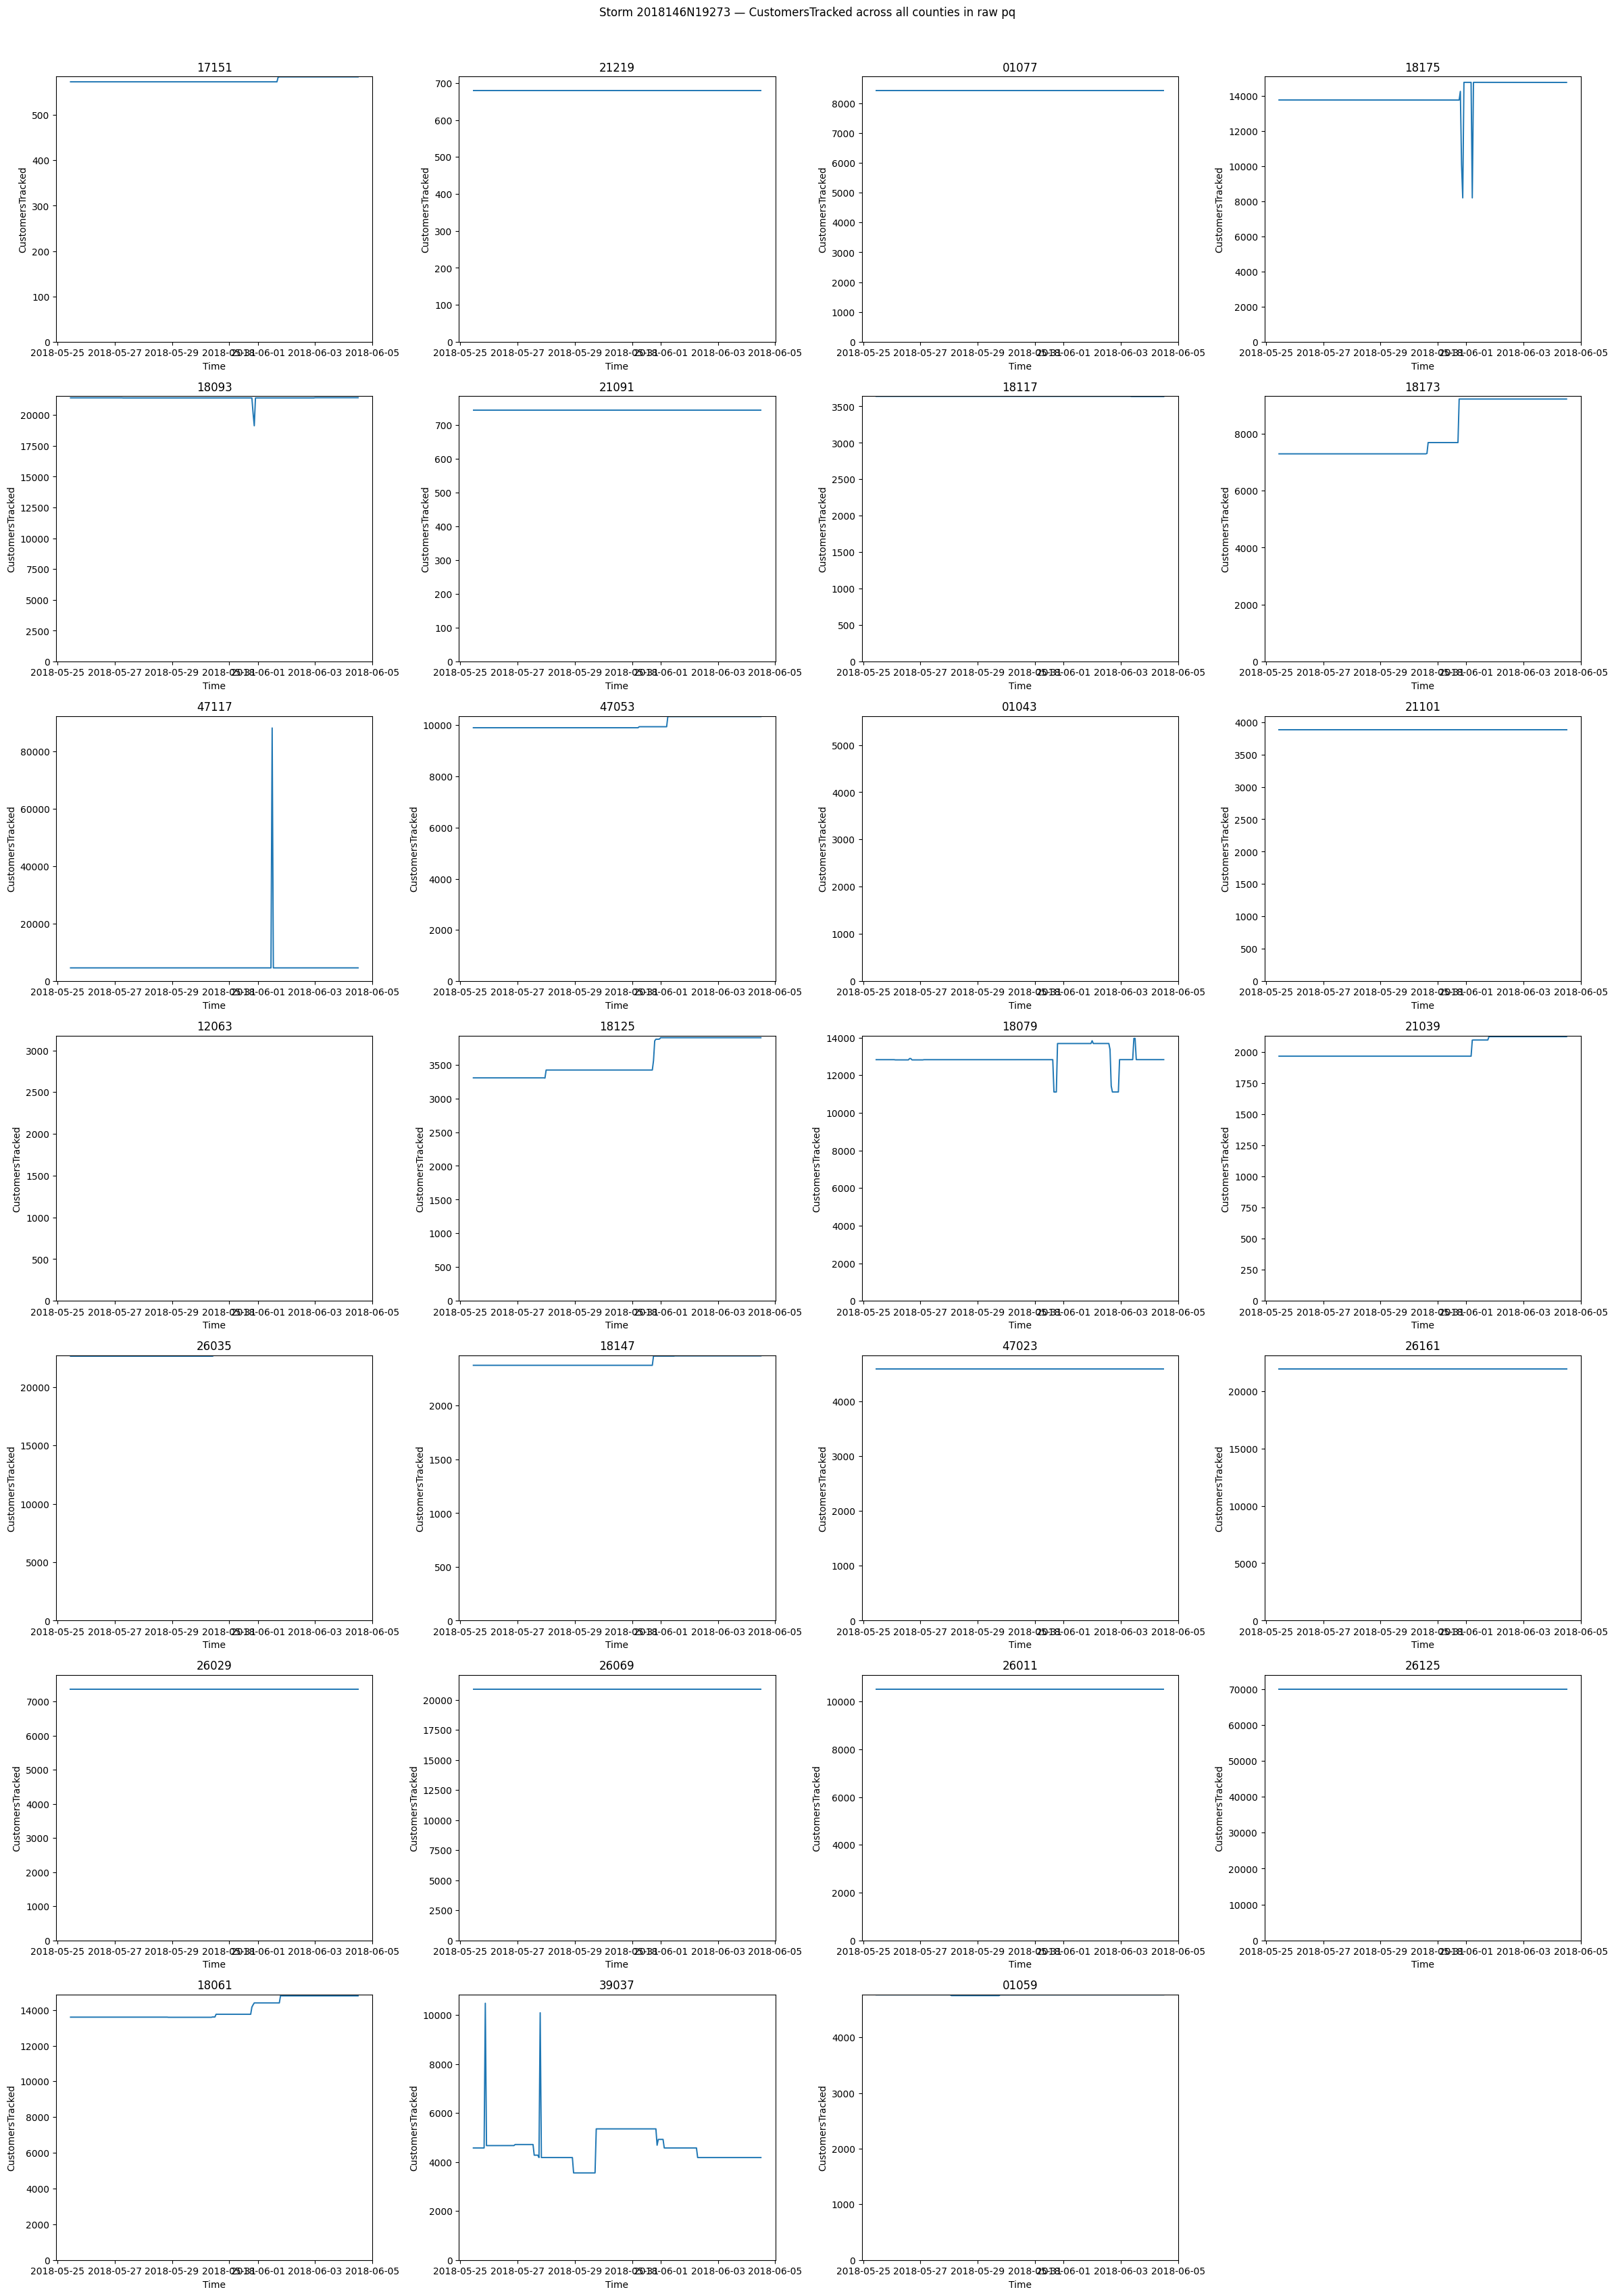

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

storm_id = "2018146N19273"

pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"
pq_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"
ib_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\ibtracs.txt"

# ---------------------------
# 1) storm footprint from POUS
# ---------------------------
pous = pd.read_csv(pous_path, low_memory=False)
storm_rows = pous[pous["storm"].astype(str) == storm_id].copy()

storm_rows["CountyFIPS"] = storm_rows["CountyFIPS"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)
storm_rows["event_start"] = pd.to_datetime(storm_rows["event_start"], errors="coerce")

counties = storm_rows["CountyFIPS"].dropna().unique().tolist()

storm_start = storm_rows["event_start"].min()
storm_end = (storm_rows["event_start"] + pd.to_timedelta(storm_rows["duration_hours"], unit="h")).max()

# modest buffer around the storm footprint
start = storm_start - pd.Timedelta(days=0.5)
end = storm_end + pd.Timedelta(days=0.5)

print("Storm ID:", storm_id)
print("Counties in POUS:", len(counties))
print("Date window:", start, "→", end)
print()

print("POUS county summary:")
print(
    storm_rows[["CountyFIPS", "event_start", "duration_hours", "county_pop"]]
    .sort_values("duration_hours", ascending=False)
    .to_string(index=False)
)

# ---------------------------
# 2) storm name lookup in IBTrACS
# ---------------------------
try:
    with open(ib_path, "r", encoding="utf-8", errors="ignore") as f:
        matches = [line.strip() for line in f if storm_id in line]
    print("\nIBTrACS matches:")
    for line in matches[:5]:
        print(line)
except Exception as e:
    print("\nIBTrACS lookup failed:", e)

# ---------------------------
# 3) load only needed counties from raw pq
# ---------------------------
frames = []

for c in counties:
    try:
        s = pd.read_parquet(
            pq_path,
            columns=["OutageFraction", "CustomersTracked"],
            filters=[
                ("CountyFIPS", "==", c),
                ("RecordDateTime", ">=", start),
                ("RecordDateTime", "<=", end),
            ],
        )

        if len(s) == 0:
            continue

        # restore index levels as columns
        s = s.reset_index()

        # standardize names
        s = s.rename(columns={
            "RecordDateTime": "datetime",
            "CountyFIPS": "CountyFIPS",
            "OutageFraction": "outageFraction",
            "CustomersTracked": "customersTracked",
        })

        s["CountyFIPS"] = s["CountyFIPS"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)
        frames.append(s)

    except Exception as e:
        print(f"Failed to load county {c}: {e}")

if not frames:
    raise ValueError("No raw timeseries rows were loaded for this storm window.")

ts = pd.concat(frames, ignore_index=True)
ts["datetime"] = pd.to_datetime(ts["datetime"], errors="coerce")
ts = ts.dropna(subset=["datetime"]).sort_values(["CountyFIPS", "datetime"]).reset_index(drop=True)

print("\nLoaded raw rows:", len(ts))
print("Counties loaded:", ts["CountyFIPS"].nunique())

summary = (
    ts.groupby("CountyFIPS", as_index=False)
      .agg(
          max_outageFraction=("outageFraction", "max"),
          max_customersTracked=("customersTracked", "max"),
          n_rows=("datetime", "size"),
          start=("datetime", "min"),
          end=("datetime", "max"),
      )
      .sort_values("max_outageFraction", ascending=False)
)

print("\nCounty summary from raw pq:")
print(summary.to_string(index=False))

# ---------------------------
# 4) plotting helper
# ---------------------------
def plot_county_grid(data, value_col, title, ylabel):
    counties_plot = summary["CountyFIPS"].tolist()
    n = len(counties_plot)
    cols = 4
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(24, 4.8 * rows))
    axes = np.array(axes).ravel()

    for ax in axes:
        ax.set_visible(False)

    for ax, county in zip(axes, counties_plot):
        g = data[data["CountyFIPS"] == county].sort_values("datetime")

        ax.set_visible(True)
        ax.plot(g["datetime"], g[value_col], linewidth=1.4)
        ax.set_title(county)
        ax.set_xlabel("Time")
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=0)

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

# ---------------------------
# 5) plots
# ---------------------------
plot_county_grid(
    ts,
    "outageFraction",
    f"Storm {storm_id} — outageFraction across all counties in raw pq",
    "outageFraction",
)

plot_county_grid(
    ts,
    "customersTracked",
    f"Storm {storm_id} — CustomersTracked across all counties in raw pq",
    "CustomersTracked",
)

Okay back to **just Florida** again to test separating into valid vs irrelevant events

Summary:
is_valid
True     92
False     7
Name: count, dtype: int64

       max_outage  hours_above_thresh                          start
count   99.000000           99.000000                             99
mean     0.716623          109.272727  2019-03-30 01:13:56.363636224
min      0.053560            0.000000            2017-07-30 21:00:00
25%      0.537959           34.500000            2017-09-11 00:00:00
50%      0.817914          101.000000            2017-09-11 08:00:00
75%      0.986472          134.500000            2021-07-05 03:30:00
max      1.000000          511.000000            2022-09-29 10:00:00
std      0.293842           98.236160                            NaN


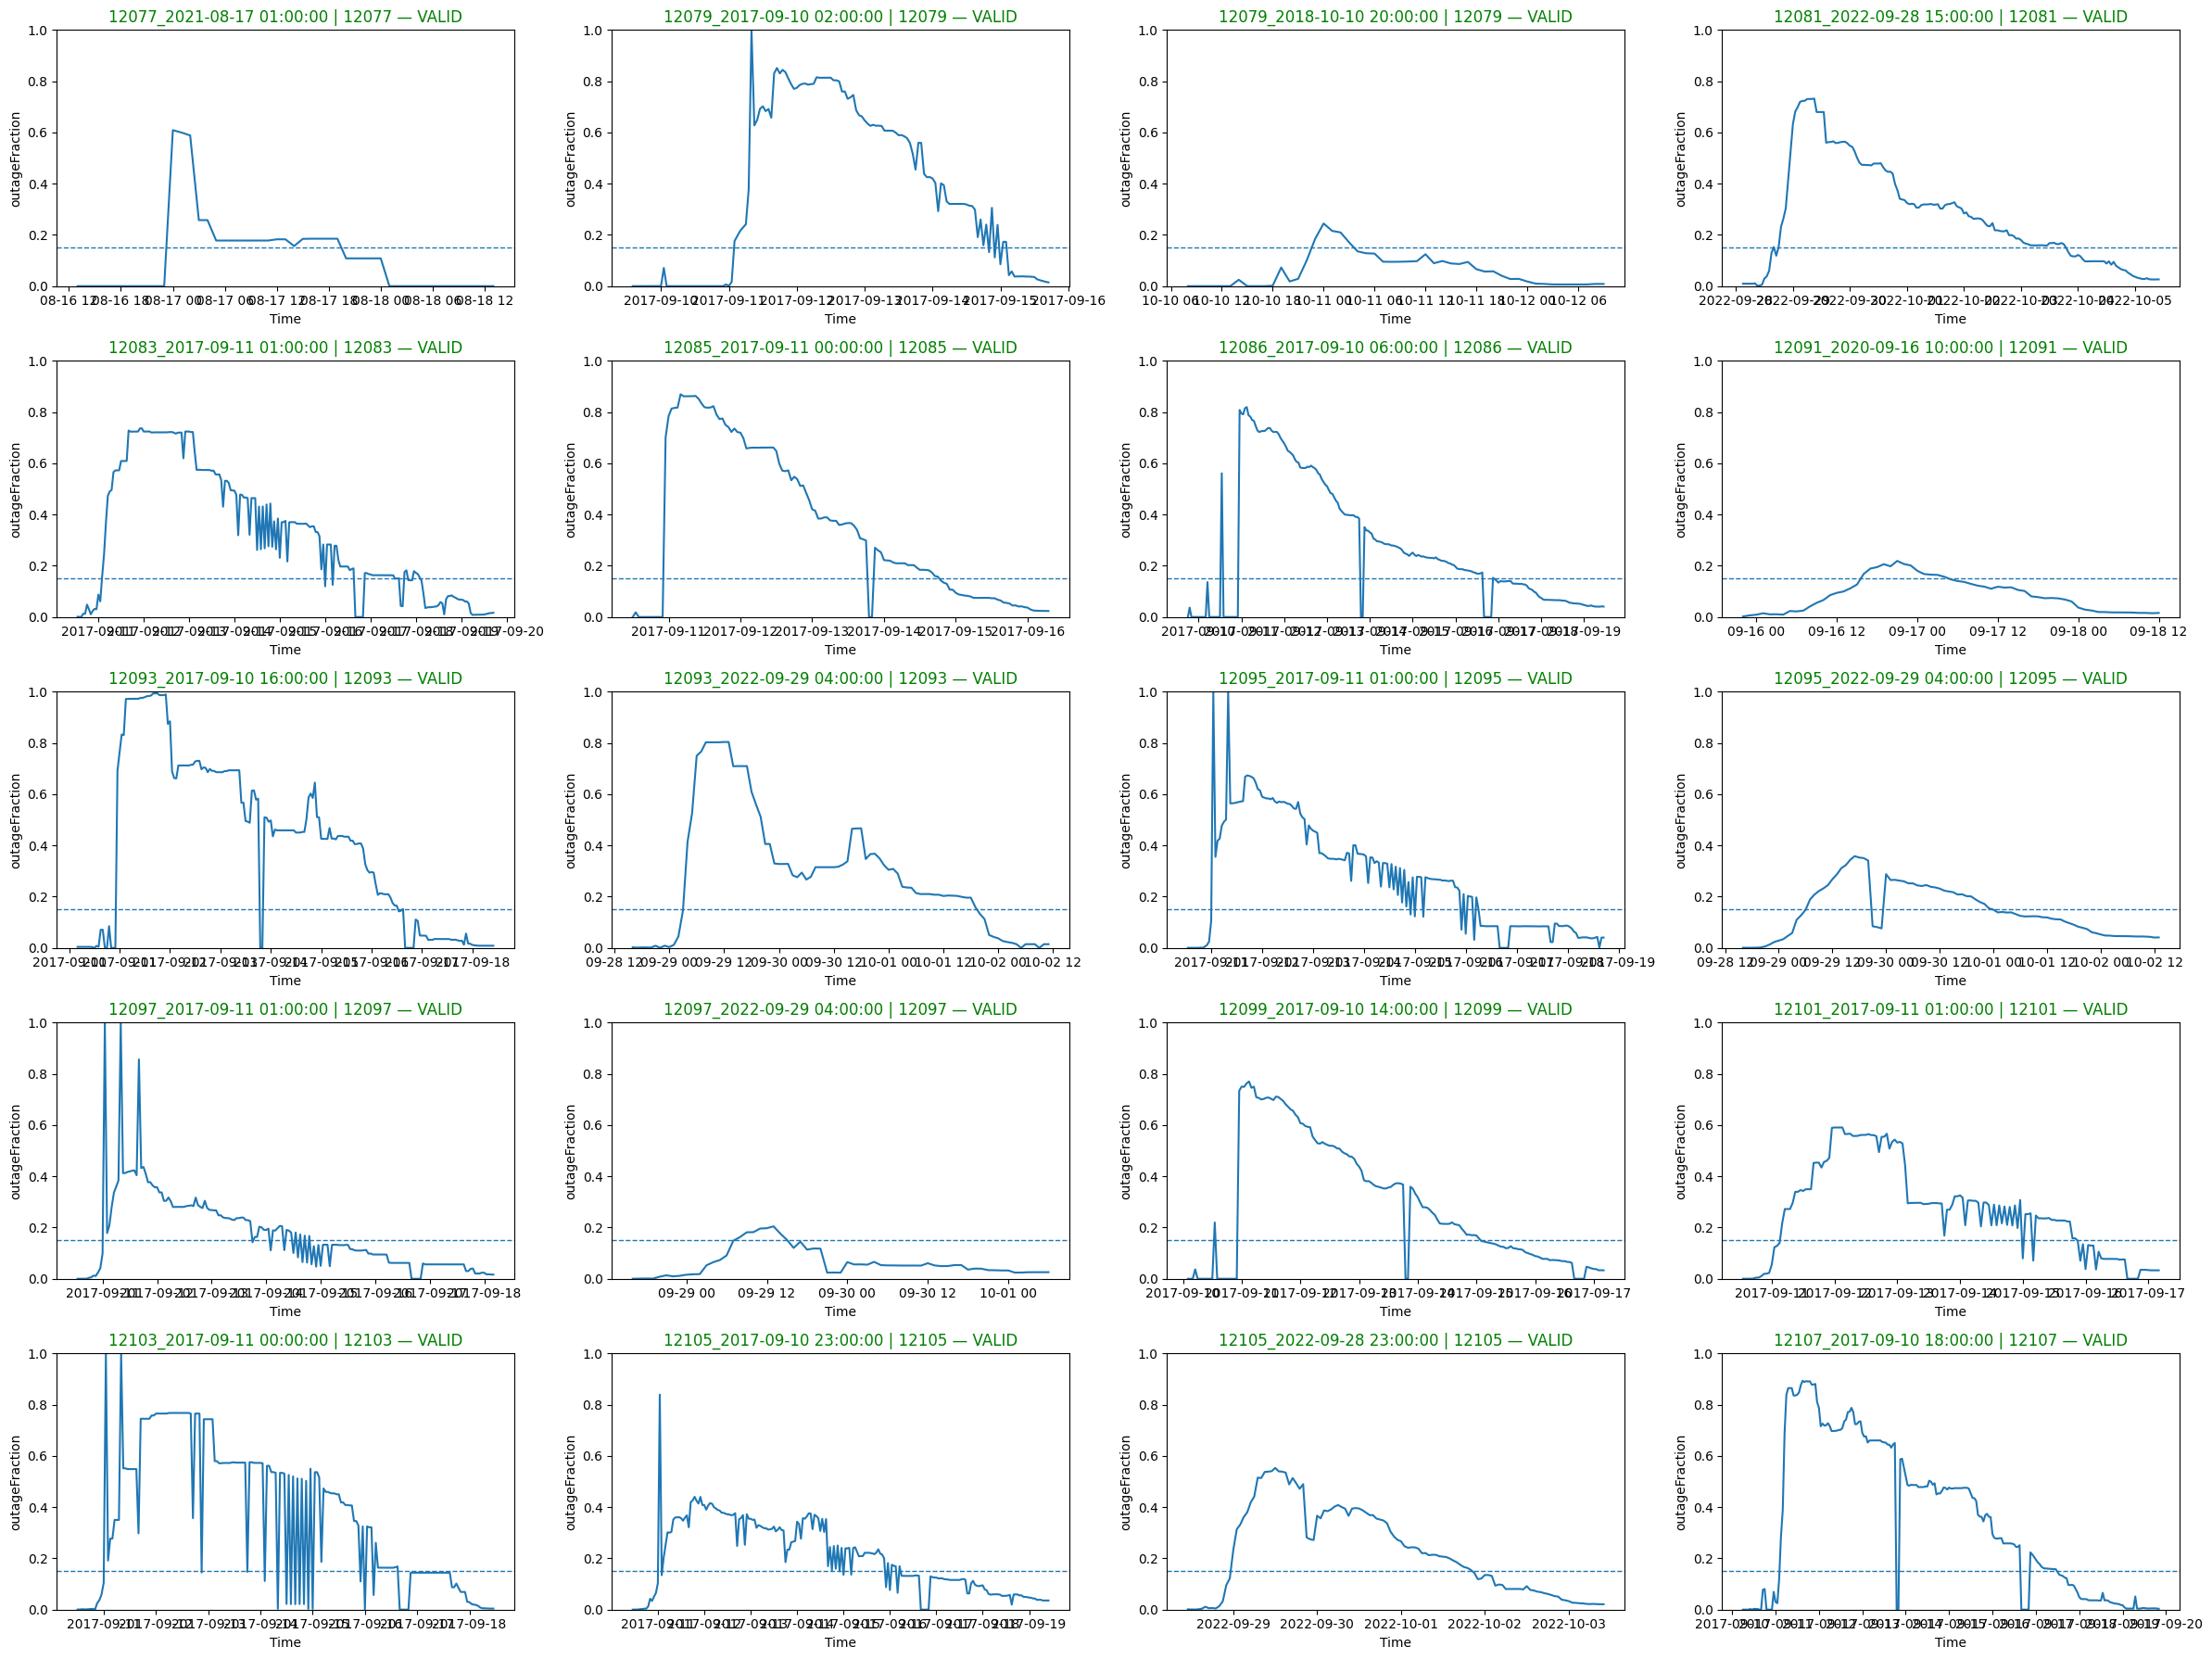

In [33]:
# CELL — classify Florida events (valid vs invalid) + visualise

# thresholds (adjust later if needed)
peak_thresh = 0.15          # minimum peak outage
min_hours_above = 4        # minimum duration above threshold

# --- 1. event-level metrics ---
event_metrics = (
    df.groupby(["event_id", "CountyFIPS"])
    .agg(
        max_outage=("outageFraction", "max"),
        hours_above_thresh=("outageFraction", lambda s: (s > peak_thresh).sum()),
        start=("event_start", "first"),
    )
    .reset_index()
)

# classify
event_metrics["is_valid"] = (
    (event_metrics["max_outage"] >= peak_thresh) &
    (event_metrics["hours_above_thresh"] >= min_hours_above)
)

print("Summary:")
print(event_metrics["is_valid"].value_counts())
print()
print(event_metrics.describe())

# --- 2. plotting (20 at a time) ---
chunk = 1
chunk = 2
chunk = 3
chunk = 4
# chunk = 5

plots_per_chunk = 20

groups = (
    event_metrics[["event_id", "CountyFIPS", "is_valid"]]
    .sort_values(["event_id", "CountyFIPS"])
    .reset_index(drop=True)
)

start = (chunk - 1) * plots_per_chunk
end = start + plots_per_chunk

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start:end].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]
    is_valid = row["is_valid"]

    g = df[
        (df["event_id"] == event_id) &
        (df["CountyFIPS"] == county_fips)
    ].sort_values("datetime")

    s = g["outageFraction"]

    ax.set_visible(True)

    # main line
    ax.plot(g["datetime"], s, linewidth=1.5)

    # colour title by validity
    title_color = "green" if is_valid else "red"
    label = "VALID" if is_valid else "INVALID"

    ax.set_title(f"{event_id} | {county_fips} — {label}", color=title_color)

    # threshold line
    ax.axhline(peak_thresh, linestyle="--", linewidth=1)

    ax.set_xlabel("Time")
    ax.set_ylabel("outageFraction")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Now incorporate interpolation for faulty data and rolling median filter for noise (since we're only predicting duration now)

Valid / invalid counts:
is_valid
True     90
False     9
Name: count, dtype: int64

       max_outage  hours_above_thresh
count   99.000000           99.000000
mean     0.716623          109.272727
std      0.293842           98.236160
min      0.053560            0.000000
25%      0.537959           34.500000
50%      0.817914          101.000000
75%      0.986472          134.500000
max      1.000000          511.000000


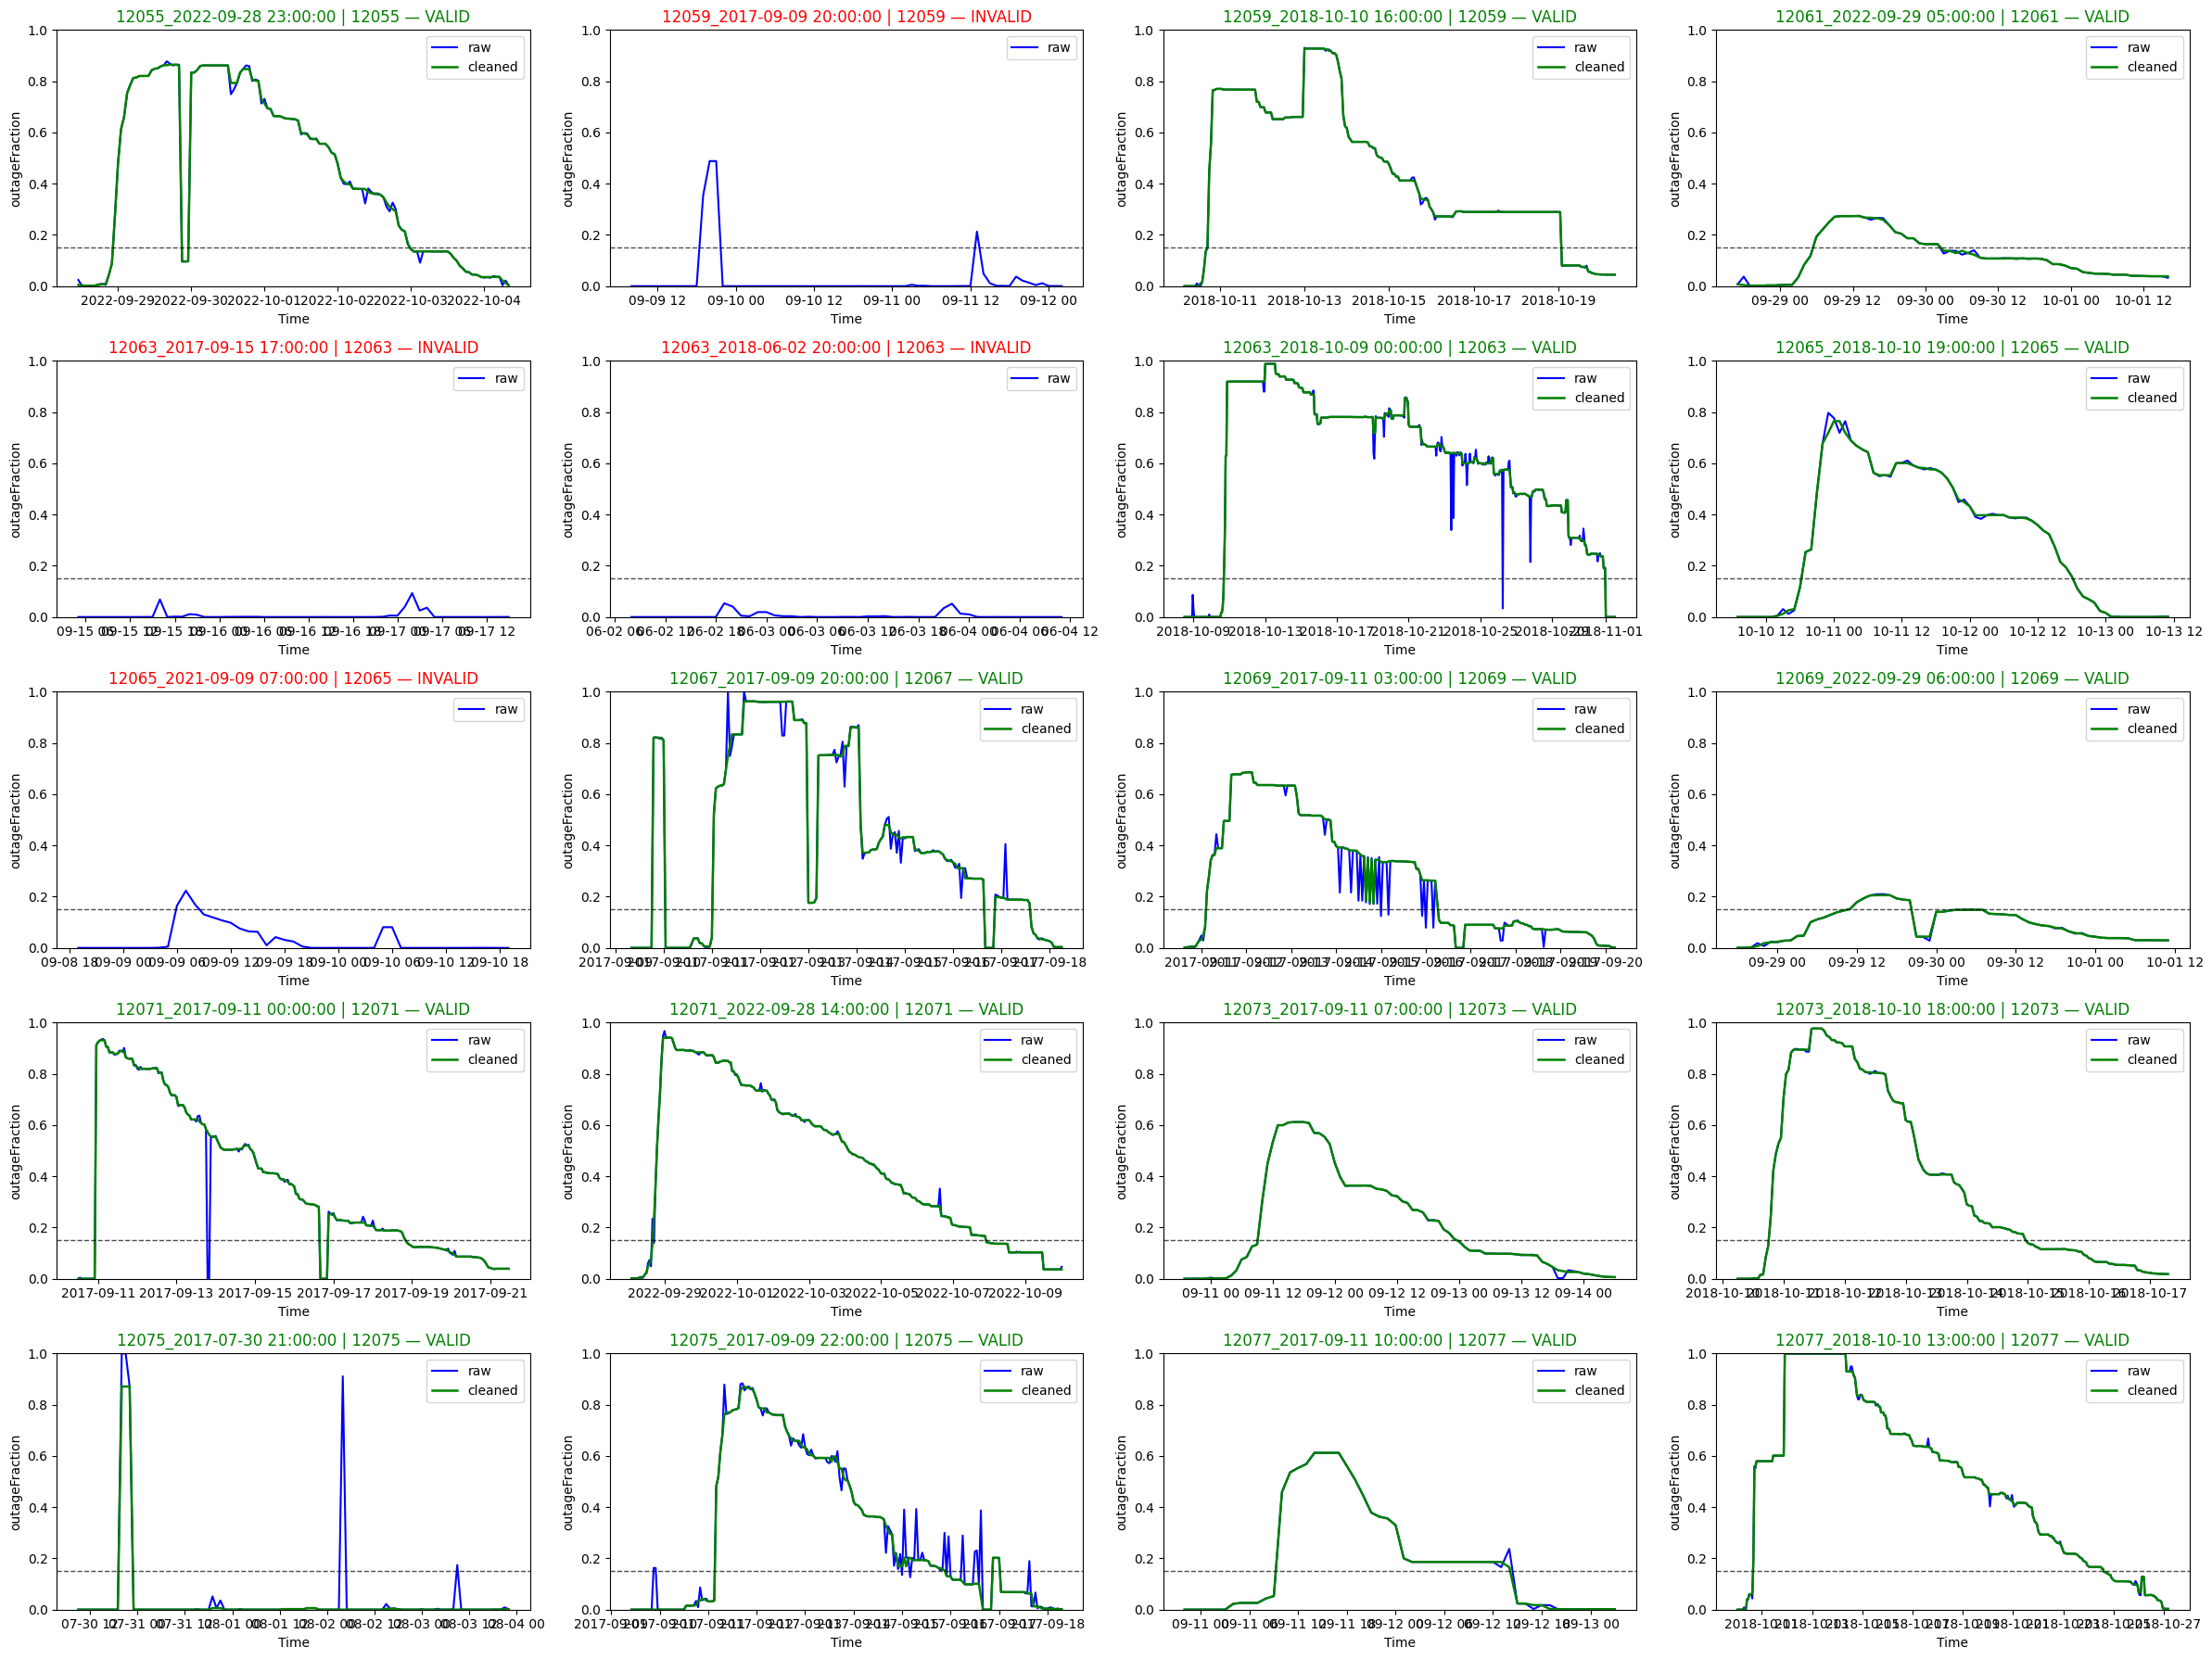

In [48]:
# CELL — Florida valid/invalid classification + 3h interpolation + 5h rolling median
# chunk controls which 20 plots are shown
chunk = 3                 # 1, 2, 3, 4, 5
plots_per_chunk = 20

peak_thresh = 0.15        # valid-event threshold
min_hours_above = 5       # valid-event duration rule

med_window = 5            # rolling median window for cleaning
max_short_run = 3         # interpolate only short anomalous runs
abs_dev_thresh = 0.15     # anomaly threshold floor
rel_dev_scale = 0.35      # anomaly threshold relative to local median

# Use the Florida dataframe already loaded in this notebook
source_df = df.copy()

# Event-level valid / invalid mask
event_metrics = (
    source_df.groupby(["event_id", "CountyFIPS"], as_index=False)
    .agg(
        max_outage=("outageFraction", "max"),
        hours_above_thresh=("outageFraction", lambda s: (s > peak_thresh).sum()),
    )
)

event_metrics["is_valid"] = (
    (event_metrics["max_outage"] >= peak_thresh) &
    (event_metrics["hours_above_thresh"] >= min_hours_above)
)

print("Valid / invalid counts:")
print(event_metrics["is_valid"].value_counts(dropna=False))
print()
print(event_metrics[["max_outage", "hours_above_thresh"]].describe())

def clean_valid_outage_series(g):
    g = g.sort_values("datetime").copy().reset_index(drop=True)
    s = g["outageFraction"].astype(float).clip(0, 1)

    # 5-hour rolling median baseline
    med = s.rolling(window=med_window, center=True, min_periods=1).median()

    # Local deviation threshold: max(floor, relative)
    dev = (s - med).abs()
    thresh = np.maximum(abs_dev_thresh, rel_dev_scale * med)
    anomaly = dev > thresh

    # Keep only short anomalous runs
    run_id = (anomaly != anomaly.shift()).cumsum()
    run_len = anomaly.groupby(run_id).transform("sum")
    short_anom = anomaly & (run_len <= max_short_run)

    # Interpolate across short anomalous runs only
    repaired = s.mask(short_anom, np.nan)
    repaired_filled = repaired.copy()
    was_interpolated = pd.Series(False, index=g.index)

    run_id_np = run_id.to_numpy()
    short_run_ids = pd.unique(run_id[short_anom])

    for rid in short_run_ids:
        pos = np.flatnonzero(run_id_np == rid)
        if len(pos) == 0 or len(pos) > max_short_run:
            continue

        left = pos[0] - 1
        right = pos[-1] + 1
        if left < 0 or right >= len(g):
            continue

        left_val = repaired.iloc[left]
        right_val = repaired.iloc[right]
        if pd.isna(left_val) or pd.isna(right_val):
            continue

        repaired_filled.iloc[pos] = np.linspace(left_val, right_val, len(pos) + 2)[1:-1]
        was_interpolated.iloc[pos] = True

    # Final light smoothing
    cleaned = repaired_filled.rolling(window=med_window, center=True, min_periods=1).median()

    g["of_rolling_median"] = med
    g["of_anomaly"] = anomaly
    g["of_short_anomaly"] = short_anom
    g["outageFraction_repaired"] = repaired_filled
    g["outageFraction_clean"] = cleaned
    g["outageFraction_was_interpolated"] = was_interpolated

    return g

# Build cleaned dataframe for valid groups only; keep invalid groups raw-only for plotting
valid_keys = set(
    event_metrics.loc[event_metrics["is_valid"], ["event_id", "CountyFIPS"]]
    .itertuples(index=False, name=None)
)

groups = (
    source_df[["event_id", "CountyFIPS"]]
    .drop_duplicates()
    .sort_values(["event_id", "CountyFIPS"])
    .reset_index(drop=True)
)

start = (chunk - 1) * plots_per_chunk
end = min(start + plots_per_chunk, len(groups))

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start:end].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]

    g_raw = source_df[
        (source_df["event_id"] == event_id) &
        (source_df["CountyFIPS"] == county_fips)
    ].sort_values("datetime").copy()

    is_valid = (event_id, county_fips) in valid_keys
    label = "VALID" if is_valid else "INVALID"
    title_color = "green" if is_valid else "red"

    ax.set_visible(True)

    # Raw series in blue
    ax.plot(g_raw["datetime"], g_raw["outageFraction"], color="blue", linewidth=1.5, label="raw")

    # Cleaned series in green only for valid events
    if is_valid:
        g_clean = clean_valid_outage_series(g_raw)
        ax.plot(
            g_clean["datetime"],
            g_clean["outageFraction_clean"],
            color="green",
            linewidth=1.8,
            label="cleaned",
        )

    ax.axhline(peak_thresh, linestyle="--", linewidth=1, color="black", alpha=0.7)

    ax.set_title(f"{event_id} | {county_fips} — {label}", color=title_color)
    ax.set_xlabel("Time")
    ax.set_ylabel("outageFraction")
    ax.set_ylim(0, 1)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()